In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from sklearn.preprocessing import StandardScaler

# Load data
data = pd.read_csv("DATASET/Plant_Parameters.csv")

# Separate features and target
target = data['Moisture']
features = data.drop('Moisture', axis=1)

# Encode categorical variable if needed
le = LabelEncoder()
features['Plant Type'] = le.fit_transform(features['Plant Type'])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# we must apply the scaling to the test set as well that we are computing for the training set
X_test_scaled = scaler.transform(X_test)


# Define the XGBoost regressor
xgb_reg = xgb.XGBRegressor(eta = 0.01, gamma = 70, learning_rate = 0.09, max_depth = 4, n_estimators = 100)

# Train the model
xgb_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred = xgb_reg.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared Score:",r2)

Mean Squared Error: 10.743255123912608
R-squared Score: 0.827047717909249


ValueError: Format '_boxpng' is not supported (supported formats: eps, jpeg, jpg, pdf, pgf, png, ps, raw, rgba, svg, svgz, tif, tiff, webp)

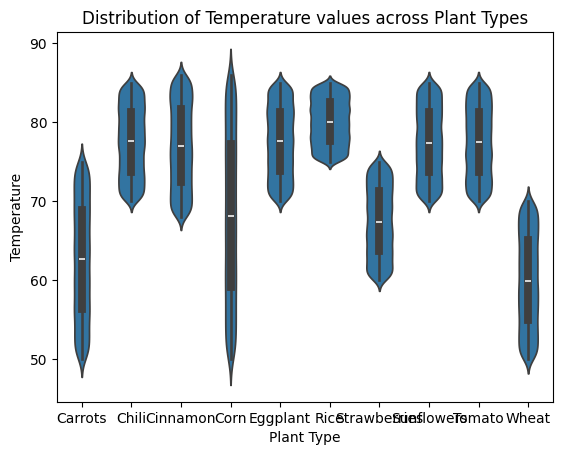

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
# Assuming your dataset is stored in a variable called 'data'
import os

# Create the img folder if it doesn't exist
if not os.path.exists('img'):
    os.makedirs('img')

# pH
sns.violinplot(x='Plant Type', y='pH', data=data)
plt.title('Distribution of pH values across Plant Types')
plt.savefig('img/pH_distribution_box.png')
plt.clf()

# Soil EC
sns.boxplot(x='Plant Type', y='Soil EC', data=data)
plt.title('Distribution of Soil EC values across Plant Types')
plt.savefig('img/soil_ec_distribution_box.png')
plt.clf()

# Moisture
sns.boxplot(x='Plant Type', y='Moisture', data=data)
plt.title('Distribution of Moisture values across Plant Types')
plt.savefig('img/moisture_distribution_box.png')
plt.clf()

# Temperature
sns.violinplot(x='Plant Type', y='Temperature', data=data)
plt.title('Distribution of Temperature values across Plant Types')
plt.savefig('img/temperature_distribution._boxpng')
plt.clf()

# Plant Type
sns.countplot(x='Plant Type', data=data)
plt.title('Count of each Plant Type')
plt.savefig('img/plant_type_count_box.png')
plt.clf()


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create the img folder if it doesn't exist
if not os.path.exists('img'):
    os.makedirs('img')

# Assuming your dataset is stored in a variable called 'data'

# Define a function to plot histograms and probability density plots
def plot_distribution(column_name):
    plt.figure(figsize=(10, 5))
    
    # Histogram
    plt.subplot(1, 2, 1)
    plt.hist(data[column_name], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(f'Histogram of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    
    # Probability Density Plot
    plt.subplot(1, 2, 2)
    sns.kdeplot(data[column_name], color='red', shade=True)
    plt.title(f'Probability Density Plot of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Density')
    
    plt.tight_layout()
    plt.savefig(f'img/{column_name}_distribution.png')
    plt.clf()

# List of columns in your dataset
columns = ['pH', 'Soil EC', 'Phosphorus', 'Potassium', 'Urea', 'T.S.P', 'M.O.P', 'Moisture', 'Temperature']

# Plot distributions for each column
for column in columns:
    plot_distribution(column)


In [16]:
import os
import matplotlib.pyplot as plt

# Create the img folder if it doesn't exist
if not os.path.exists('img'):
    os.makedirs('img')

# Actual vs. Predicted Moisture Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red')
plt.title('Actual vs. Predicted Moisture')
plt.xlabel('Actual Moisture')
plt.ylabel('Predicted Moisture')
plt.grid(True)
plt.savefig('img/actual_vs_predicted_moisture.png')
plt.clf()

# Feature Importance Plot
feature_importance = xgb_reg.feature_importances_
sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(X_train_scaled.shape[1]), feature_importance[sorted_idx], align='center')
plt.xticks(range(X_train_scaled.shape[1]), X_train.columns[sorted_idx], rotation=90)
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.savefig('img/feature_importance.png')
plt.clf()


<Figure size 800x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>